In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned IoT data from Week 6
df = pd.read_csv("cleaned_iot_data.csv")

# Display the first five records
print("First five records:")
display(df.head())

First five records:


,timestamp,device_id,data_type,data_value
0,2026-05-23 22:55:20.319812,PAT440,Oxygen Level,99%
1,2026-05-23 15:18:20.319812,PAT434,Heart Rate,93 bpm
2,2026-05-24 01:06:20.319812,PAT355,Heart Rate,79 bpm
3,2026-05-23 19:19:20.319812,PAT134,Oxygen Level,96%
4,2026-05-24 00:08:20.319812,PAT922,Blood Pressure,127/85 mmHg


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nSensor types:")
print(df["data_type"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(100, 4)

Column names:
['timestamp', 'device_id', 'data_type', 'data_value']

Sensor types:
data_type
Oxygen Level        27
Body Temperature    27
Blood Pressure      24
Heart Rate          22
Name: count, dtype: int64

Missing values:
timestamp     0
device_id     0
data_type     0
data_value    0
dtype: int64


In [5]:
# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

# Create numeric_value if it is missing
if "numeric_value" not in df.columns:
    df["numeric_value"] = pd.to_numeric(
        df["data_value"]
          .astype("string")
          .str.extract(r"([-+]?\d*\.?\d+)")[0],
        errors="coerce"
    )

# Remove records with invalid timestamps or numeric values
df = df.dropna(
    subset=["timestamp", "numeric_value"]
)

# Sort records by timestamp
df = df.sort_values("timestamp")

print("Data after timestamp conversion:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Data after timestamp conversion:


,timestamp,device_id,data_type,data_value,numeric_value
58,2026-05-23 12:23:20.322812,PAT604,Blood Pressure,104/83 mmHg,104.0
26,2026-05-23 12:49:20.320813,PAT420,Heart Rate,78 bpm,78.0
82,2026-05-23 13:00:20.323812,PAT185,Oxygen Level,96%,96.0
84,2026-05-23 13:01:20.323812,PAT241,Oxygen Level,99%,99.0
16,2026-05-23 13:08:20.320813,PAT254,Blood Pressure,137/70 mmHg,137.0



Columns:
['timestamp', 'device_id', 'data_type', 'data_value', 'numeric_value']


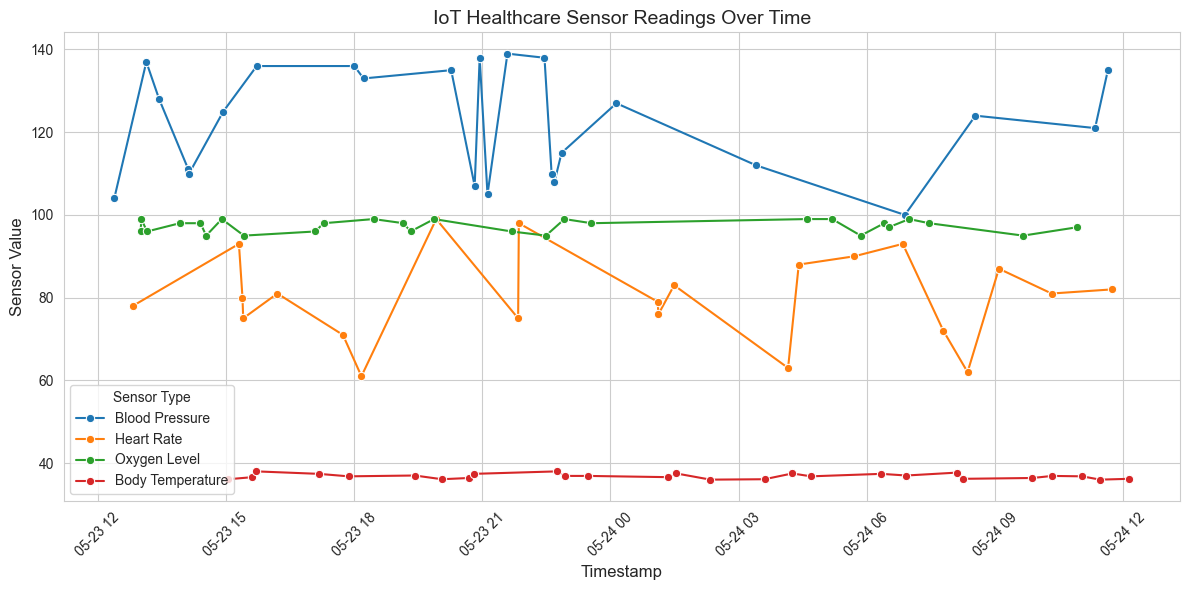

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="numeric_value",
    hue="data_type",
    marker="o"
)

plt.title("IoT Healthcare Sensor Readings Over Time", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Sensor Value", fontsize=12)

plt.xticks(rotation=45)
plt.legend(title="Sensor Type")

plt.tight_layout()
plt.show()

In [7]:
plt.savefig("week7_iot_sensor_line_plot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>